In [2]:
# Get what we need （MacKay, R. S., Johnson, S. & Sansom, B. How directed is a directed network?
# Royal Society Open Science 7 (2020). URL https://royalsocietypublishing.org/
# doi/10.1098/rsos.201138.）
import trophic_tools as ta # will need to ensure on path
import networkx as nx
import pandas as pd
import numpy as np 

In [3]:
def flatten_matrix(matrix):
    diag_mask = np.eye(matrix.shape[0], dtype=bool)
    flat_array = matrix[~diag_mask].flatten()
    return flat_array 

In [4]:
file_path = r"D:\7_Research\3_projects\20250104_MacaqueHuman\Results\main_files\Directional_Connectome"
directional_conn = pd.read_csv(f"{file_path}/DirectionalConnectome_D99_HCPex_LR_Log10weighted_20250715.csv", header=None)
directional_conn = directional_conn.values
directional_conn_len = pd.read_csv(f"{file_path}/DirectionalConnectome_D99_HCPex_LR_length_20250715.csv", header=0, index_col=0)
directional_conn_len = directional_conn_len.values
nodirectional_conn = pd.read_csv(f"{file_path}/connectivity_HCP-YA100_streamline_Log10weighted_20250715.csv", header=0, index_col=0)
nodirectional_conn = nodirectional_conn.values
nodirectional_conn_len = pd.read_csv(f"{file_path}/connectivity_HCP-YA100_streamline_length_ranked_20250715.csv", header=0, index_col=0)
nodirectional_conn_len = nodirectional_conn_len.values
regions_coordinates = pd.read_csv(f"{file_path}/HCPmmp_HCPex_node_coordinate_ranked.csv")
region_names = np.array(regions_coordinates["HCP_MMP_name"].tolist())
regions_coordinate = regions_coordinates[['x','y','z']].values

In [5]:
Nets = ["Visual1",              "Visual2",             
 "Auditory",             "Language",             "Somatomotor",         
 "Cingulo-Opercular",    "Dorsal-Attention",     "Ventral-Multimodal",  
 "Orbito-Affective",     "Posterior-Multimodal", "Default",             
 "Frontoparietal", 'subcortex']
Nets = np.array(Nets)
Network = np.array(regions_coordinates["NETWORK"].tolist())
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
# 定义颜色列表 (RGB 或十六进制格式)
colors = ["#6EB4E1","#3366CC",
            "#CC3333", "#E2593D", "#DDA036","#FFFF99","#FFFF00",
            "#993399","#6633CC", "#BC249F", "#339933" ,
            "#66CC33", "gray"]

# 创建自定义 colormap
custom_cmap = ListedColormap(colors, name='custom_cmap')

Text(0.5, 1.0, 'symm-directional connectome')

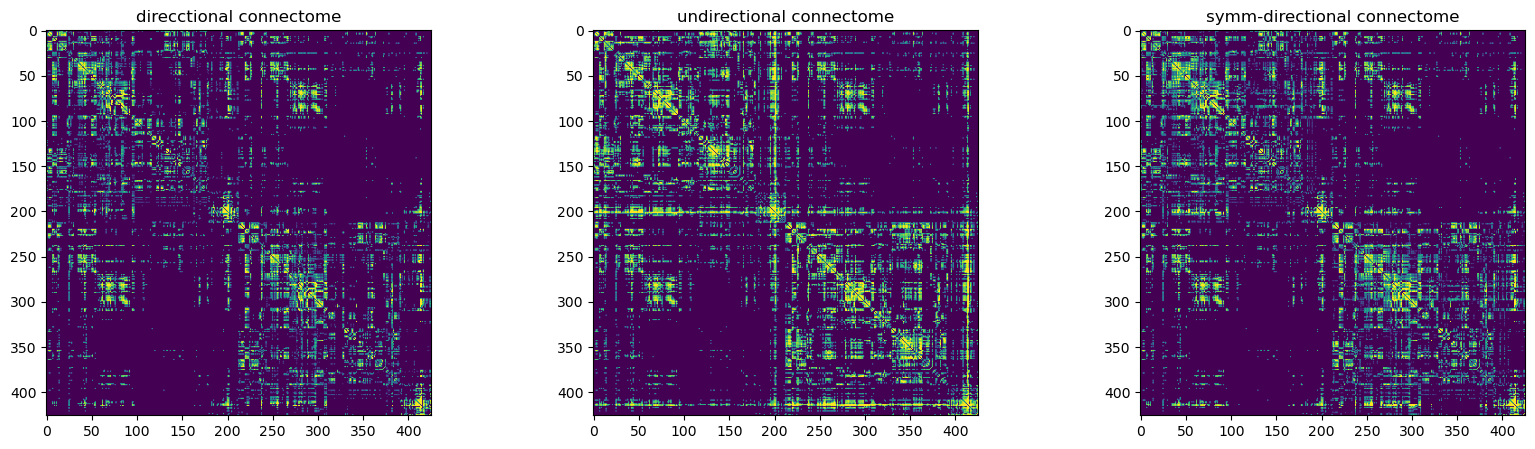

In [7]:
# symmetrilized directional connectome
mask = np.zeros(directional_conn.shape)
mask[directional_conn > 0] = 1
mask = mask + mask.T
mask[mask > 0] = 1
symm_directional_conn = nodirectional_conn * mask
symm_directional_conn_len = nodirectional_conn_len * mask

# keep top 20% weights in nodirectional_conn
threshold = np.percentile(nodirectional_conn[nodirectional_conn > 0], (100 - (np.sum(mask)/(directional_conn.shape[1]*directional_conn.shape[0]))*100) )
sparse_nodirectional_conn = np.where(nodirectional_conn >= threshold, nodirectional_conn, 0)
np.fill_diagonal(sparse_nodirectional_conn, 0)
mask = np.zeros(sparse_nodirectional_conn.shape)
mask[sparse_nodirectional_conn > 0] = 1
saparse_nodirectional_conn_len = nodirectional_conn_len * mask
np.fill_diagonal(saparse_nodirectional_conn_len, 0)

fig, axs = plt.subplots(1, 3, sharex=False, figsize=(20, 5))
camp = plt.cm.viridis
im0 = axs[0].imshow(directional_conn, vmin=0, vmax=3 , cmap=camp)
axs[0].set_title("direcctional connectome")
im0 = axs[1].imshow(sparse_nodirectional_conn , vmin=0, vmax=3 , cmap=camp)
axs[1].set_title("undirectional connectome")
im0 = axs[2].imshow(symm_directional_conn , vmin=0, vmax=3 , cmap=camp)
axs[2].set_title("symm-directional connectome")

Trophic incoherence = 0.79732


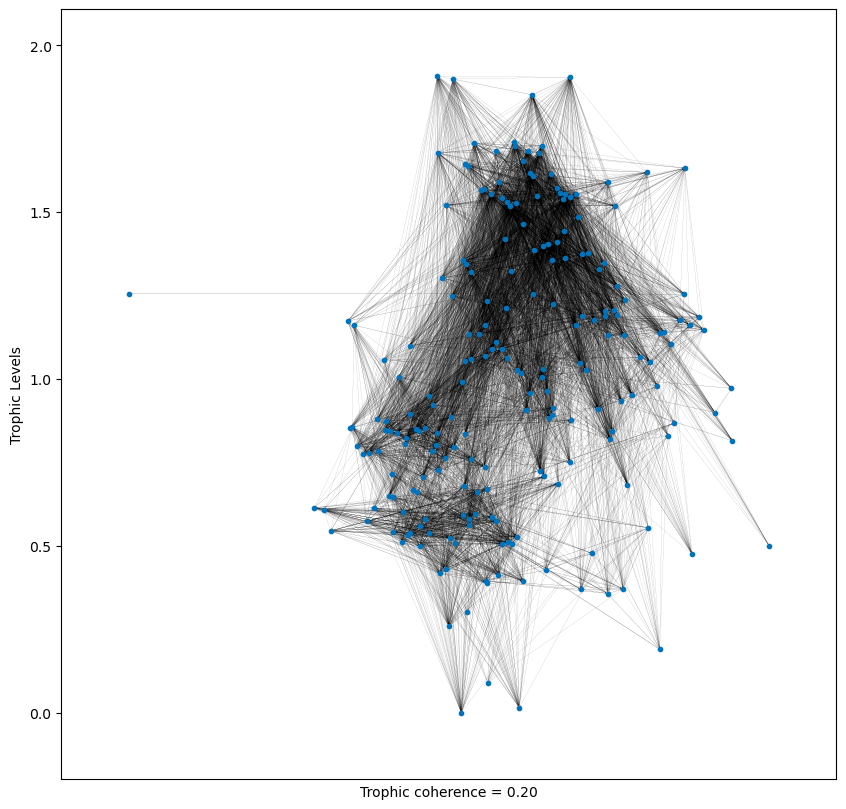

In [9]:
# left hemisphere only
adj_matrix = directional_conn.copy()
adj_matrix[adj_matrix > 0] = 1
adj_matrix = adj_matrix[0:213, 0:213]
G = nx.from_numpy_array(adj_matrix, create_using=nx.DiGraph)
ta.trophic_levels(G)
ta.trophic_plot(G,k=1)
F_l, h_l = ta.trophic_incoherence(G)
print('Trophic incoherence =',round(F_l,5))

Trophic incoherence = 0.80954


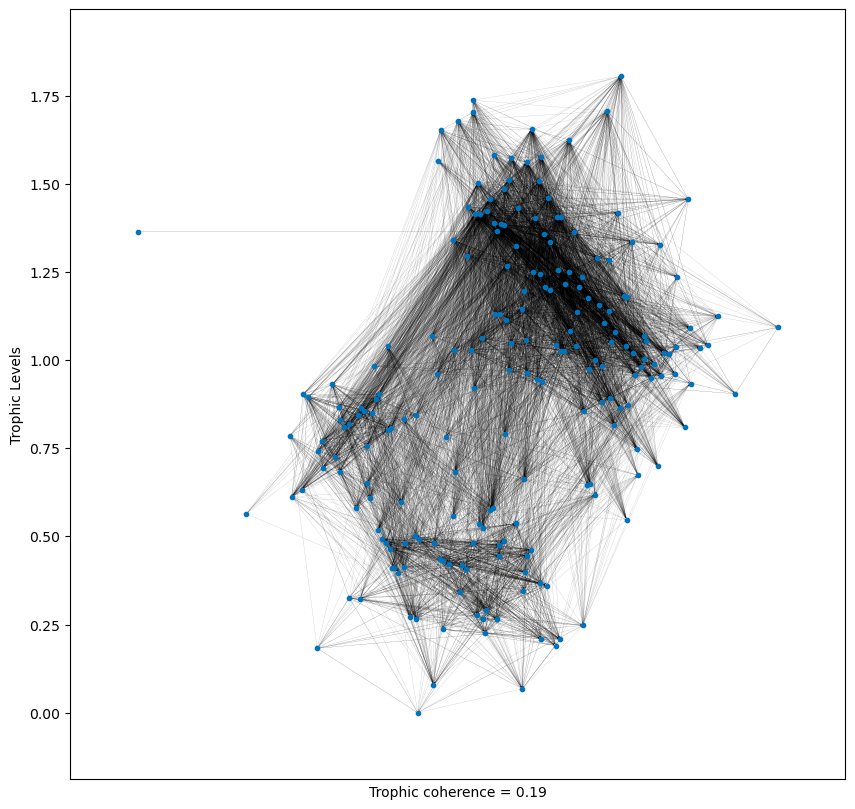

In [10]:
# right hemisphere only
adj_matrix = directional_conn.copy()
adj_matrix[adj_matrix > 0] = 1
adj_matrix = adj_matrix[213:426, 213:426]
G = nx.from_numpy_array(adj_matrix, create_using=nx.DiGraph)
ta.trophic_levels(G)
ta.trophic_plot(G,k=1)
F_r, h_r = ta.trophic_incoherence(G)
print('Trophic incoherence =',round(F_r,5))

Trophic incoherence = 0.86341


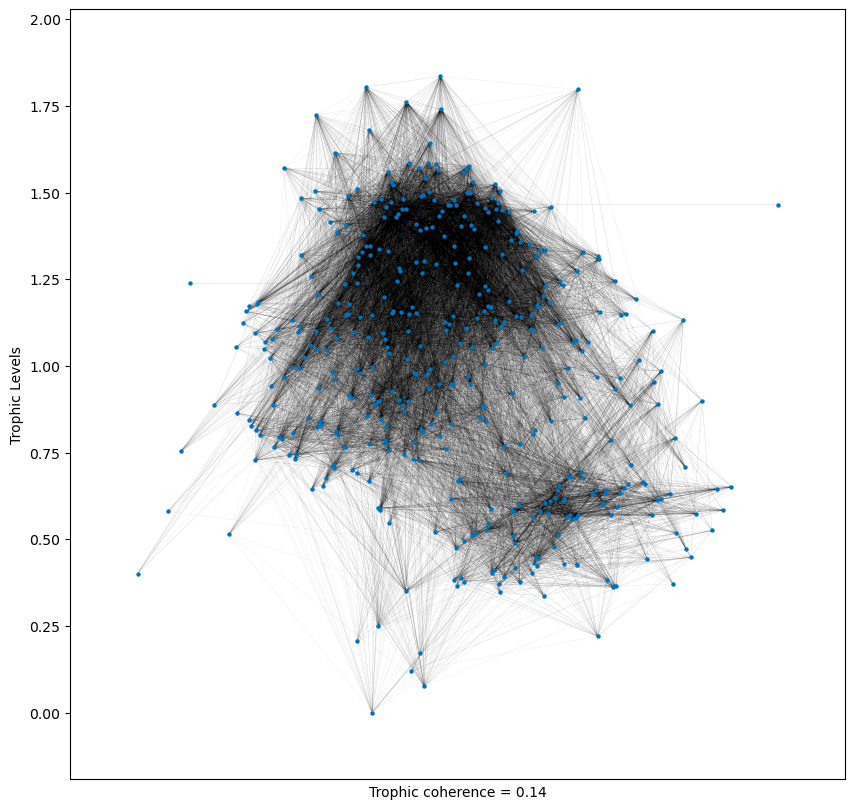

In [11]:
# right hemisphere only
adj_matrix = directional_conn.copy()
adj_matrix[adj_matrix > 0] = 1
G = nx.from_numpy_array(adj_matrix, create_using=nx.DiGraph)
ta.trophic_levels(G)
ta.trophic_plot(G,k=1)
F_r, h_r = ta.trophic_incoherence(G)
print('Trophic incoherence =',round(F_r,5))